In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all your data here at once
df26 = pd.read_csv('data/tn_2026_results.csv')
df21 = pd.read_csv('data/tn_2021_results.csv')
master = pd.read_csv('data/constituency_master.csv')

In [17]:
# Strip whitespace from column names to avoid KeyErrors
df26.columns = df26.columns.str.strip()
df21.columns = df21.columns.str.strip()

In [18]:
# Calculate winners and count seats
winners = df26.sort_values('votes', ascending=False).drop_duplicates('ac_number')
seat_counts = winners['party'].value_counts()
print(seat_counts)

party
TVK       108
DMK        59
AIADMK     47
INC         5
PMK         4
VCK         2
CPI         2
IUML        2
CPI(M)      2
DMDK        1
AMMK        1
BJP         1
Name: count, dtype: int64


In [19]:
total_votes = df26['votes'].sum()
vote_share = df26.groupby('party')['votes'].sum() / total_votes * 100
print(vote_share.sort_values(ascending=False))

party
TVK                                       34.924513
DMK                                       24.185214
AIADMK                                    21.211014
NTK                                        3.999133
INC                                        3.368153
                                            ...    
Indian Christian Front                     0.000172
Indhia Kudiarasu Katchi                    0.000166
Tamilnadu Mahatma Gandhi Makkal Katchi     0.000144
ALL PENSIONER'S PARTY                      0.000112
Makkalatchi Katchi                         0.000093
Name: votes, Length: 105, dtype: float64


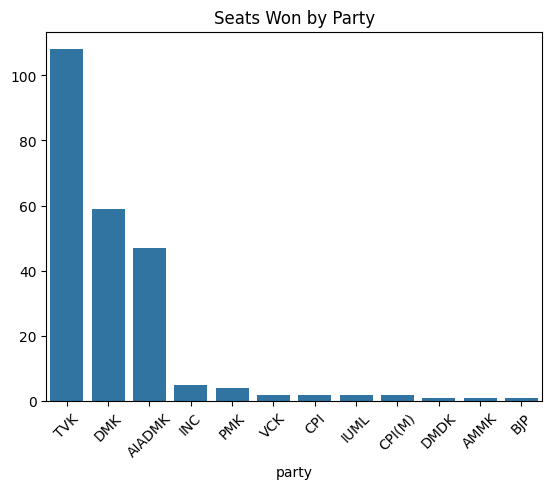

Plot saved as seats_won.png


<Figure size 640x480 with 0 Axes>

In [21]:
# Plotting your results so you can include them in your slides
sns.barplot(x=seat_counts.index, y=seat_counts.values)
plt.title("Seats Won by Party")
plt.xticks(rotation=45)
plt.show()

# Save the plot as a high-quality image for your presentation
plt.savefig('seats_won.png', dpi=300, bbox_inches='tight')
print("Plot saved as seats_won.png")

In [22]:
# Calculate turnout increase
df26['turnout_diff'] = df26['turnout'] - df21['turnout']

# Get top 5 constituencies with the largest increase
top_5_turnout = df26.groupby('ac_number')['turnout_diff'].first().sort_values(ascending=False).head(5)
print("Top 5 Constituencies by Turnout Surge:")
print(top_5_turnout)

Top 5 Constituencies by Turnout Surge:
ac_number
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
Name: turnout_diff, dtype: float64
